In [15]:
# Import required libraries

import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import preprocess_data

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
import numpy as np

In [4]:
# Load and preprocess data

X_train, X_test, y_train, y_test = preprocess_data(
    "../data/online_gaming_behavior_dataset.csv"
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# Check class distribution
print("Class distribution:\n", y_train.value_counts(normalize=True))

Training shape: (37203, 18)
Testing shape: (8007, 18)
Class distribution:
 EngagementLevel
Medium    0.333333
Low       0.333333
High      0.333333
Name: proportion, dtype: float64


In [5]:
print(y_train.unique())
print(y_test.unique())

<StringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str


In [9]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=5,         # prevent overfitting
    min_samples_split=5,
    random_state=42
)
dt_model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [10]:
# Predictions
y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)  # For ROC AUC

In [11]:
# Evaluation Metrics
# Accuracy
acc = accuracy_score(y_test, y_pred)
# Precision (weighted)
prec = precision_score(y_test, y_pred, average='weighted')
# Recall (weighted)
rec = recall_score(y_test, y_pred, average='weighted')
# F1 Score (weighted)
f1 = f1_score(y_test, y_pred, average='weighted')

In [12]:
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9025
Precision: 0.9030
Recall: 0.9025
F1 Score: 0.9025


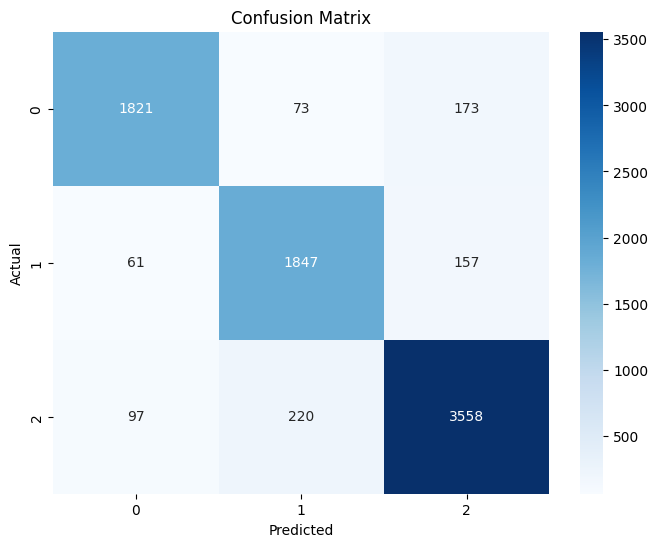

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
# ROC AUC - One-vs-Rest
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
roc_auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
print(f"ROC AUC (One-vs-Rest, Macro): {roc_auc:.4f}")

ROC AUC (One-vs-Rest, Macro): 0.9396


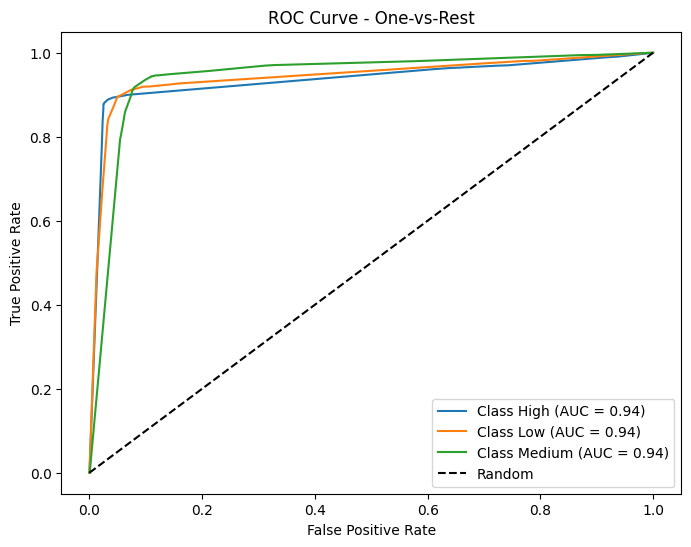

In [18]:
# ROC Curve for each class
plt.figure(figsize=(8,6))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - One-vs-Rest')
plt.legend(loc='lower right')
plt.show()